In [1]:
# Cell 1 — Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# Project paths (notebook is inside notebooks/, so go up one level)
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_EXTERNAL = PROJECT_ROOT / "data" / "external"

print("Project root:", PROJECT_ROOT)
print("Raw data dir exists:", DATA_RAW.exists())
print("External data dir exists:", DATA_EXTERNAL.exists())

Project root: C:\Users\Anushka\OneDrive\Desktop\Project_Resume
Raw data dir exists: True
External data dir exists: True


In [2]:
# Cell 2 — Load Resume dataset
resume_df = pd.read_csv(DATA_RAW / "Resume.csv")

print("Shape:", resume_df.shape)
print("\nColumns and dtypes:")
print(resume_df.dtypes)
print("\nFirst 3 rows (selected columns):")
print(resume_df[["ID", "Category"]].head(3))
print("\nMissing values per column:")
print(resume_df.isnull().sum())
print("\nDuplicate IDs:", resume_df["ID"].duplicated().sum())
print("Duplicate full rows:", resume_df.duplicated().sum())

Shape: (2484, 4)

Columns and dtypes:
ID              int64
Resume_str     object
Resume_html    object
Category       object
dtype: object

First 3 rows (selected columns):
         ID Category
0  16852973       HR
1  22323967       HR
2  33176873       HR

Missing values per column:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Duplicate IDs: 0
Duplicate full rows: 0


Number of unique categories: 24

Counts per category:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


C:\Users\Anushka\AppData\Local\Temp\ipykernel_26016\1145268574.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette="viridis")


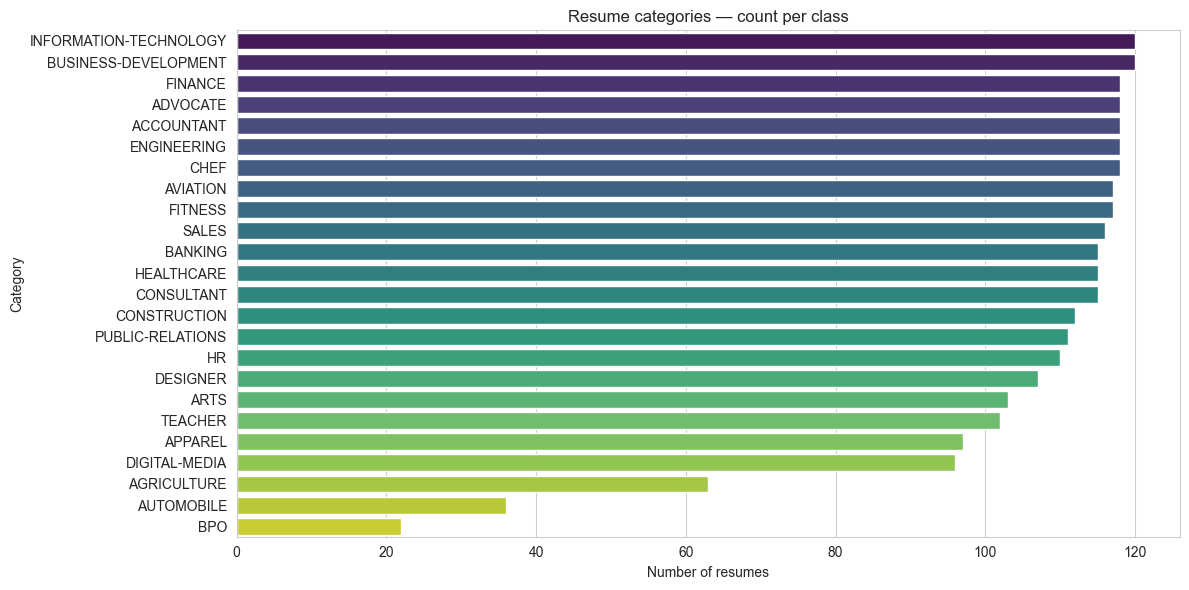

In [3]:
# Cell 3 — Category distribution
category_counts = resume_df["Category"].value_counts()
print("Number of unique categories:", resume_df["Category"].nunique())
print("\nCounts per category:")
print(category_counts)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.values, y=category_counts.index, palette="viridis")
plt.title("Resume categories — count per class")
plt.xlabel("Number of resumes")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

Text length (chars) — summary:
count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: text_len, dtype: float64

Word count — summary:
count    2484.000000
mean      811.325684
std       371.006906
min         0.000000
25%       651.000000
50%       757.000000
75%       933.000000
max      5190.000000
Name: word_count, dtype: float64


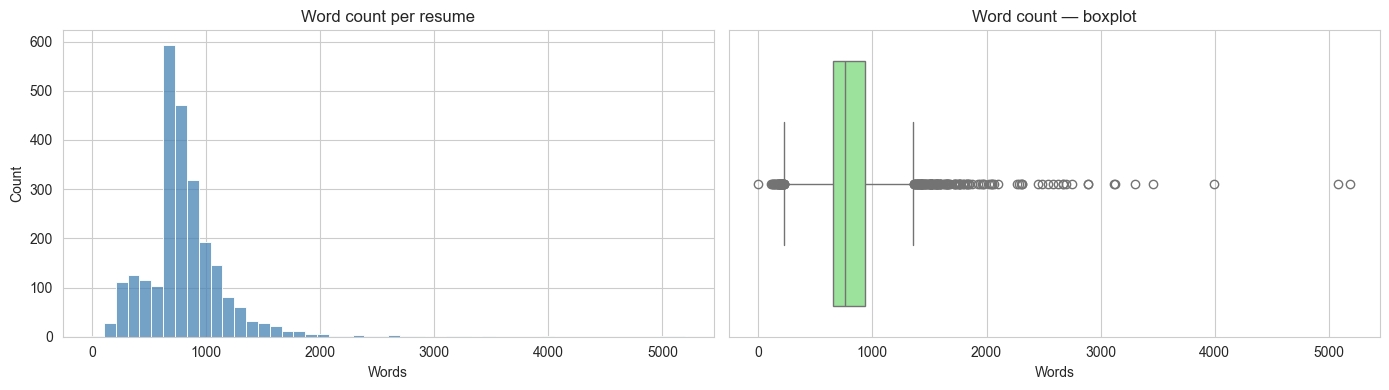

In [4]:
# Cell 4 — Resume text length
resume_df["text_len"] = resume_df["Resume_str"].astype(str).str.len()
resume_df["word_count"] = resume_df["Resume_str"].astype(str).str.split().str.len()

print("Text length (chars) — summary:")
print(resume_df["text_len"].describe())
print("\nWord count — summary:")
print(resume_df["word_count"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(resume_df["word_count"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Word count per resume")
axes[0].set_xlabel("Words")

sns.boxplot(x=resume_df["word_count"], ax=axes[1], color="lightgreen")
axes[1].set_title("Word count — boxplot")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

In [5]:
# Cell 5 — Sample one resume per category (first 500 chars)
for cat in resume_df["Category"].unique()[:5]:   # first 5 categories to keep output readable
    sample = resume_df[resume_df["Category"] == cat]["Resume_str"].iloc[0]
    print(f"\n===== {cat} =====")
    print(sample[:500].replace("\n", " "))
    print("...")


===== HR =====
         HR ADMINISTRATOR/MARKETING ASSOCIATE  HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task
...

===== DESIGNER =====
         DESIGNER       Summary     Designer with more than 15 years in product design, manufacturing, exhibit design and visual merchandising,  with comprehensive management and logistics experience who thrives in dynamically changing environments.             Highlights          Design processing expertise  Proficient in AutoCAD  Adobe Photoshop  Concept development  Product specifications  Color and material application  Strong leader  Proficient wit

In [6]:
# Cell 6 — ESCO skills
esco_df = pd.read_csv(DATA_EXTERNAL / "skills_en.csv")

print("Shape:", esco_df.shape)
print("\nColumns:", list(esco_df.columns))
print("\nMissing values per column:")
print(esco_df.isnull().sum())
print("\nSample preferred labels:")
print(esco_df["preferredLabel"].head(10).tolist())
print("\nSkill type counts:")
print(esco_df["skillType"].value_counts())

Shape: (13960, 13)

Columns: ['conceptType', 'conceptUri', 'skillType', 'reuseLevel', 'preferredLabel', 'altLabels', 'hiddenLabels', 'status', 'modifiedDate', 'scopeNote', 'definition', 'inScheme', 'description']

Missing values per column:
conceptType           0
conceptUri            0
skillType             5
reuseLevel            5
preferredLabel        0
altLabels            18
hiddenLabels      13807
status                0
modifiedDate          0
scopeNote         13724
definition        13958
inScheme              0
description           0
dtype: int64

Sample preferred labels:
['manage musical staff', 'supervise correctional procedures', 'apply anti-oppressive practices', 'control compliance of railway vehicles regulations', 'identify available services', 'perform toxicological studies', 'ensure coquille uniformity', 'Haskell', 'show initiative', 'train staff to reduce food waste']

Skill type counts:
skillType
skill/competence    10734
knowledge            3221
Name: count, dt

Skills with 0 alt labels: 18
Skills with 1+ alt labels: 13942

Distribution of alt label counts:
count    13960.000000
mean         6.210172
std          3.107010
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         78.000000
Name: alt_count, dtype: float64


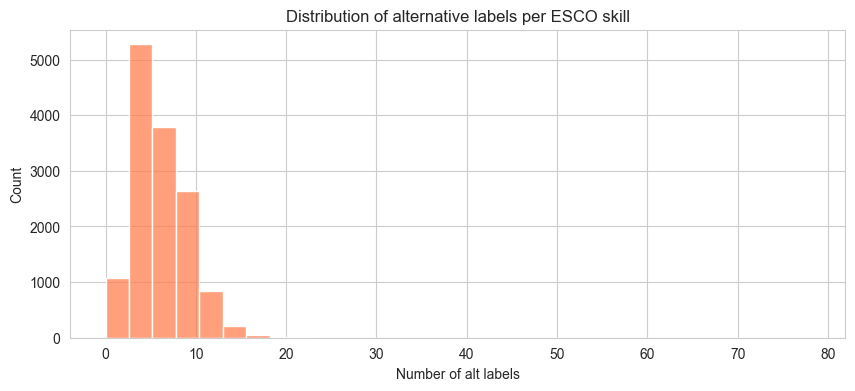

In [7]:
# Cell 7 — alt label coverage
esco_df["alt_count"] = esco_df["altLabels"].fillna("").apply(lambda x: len(x.split("\n")) if x else 0)

print("Skills with 0 alt labels:", (esco_df["alt_count"] == 0).sum())
print("Skills with 1+ alt labels:", (esco_df["alt_count"] > 0).sum())
print("\nDistribution of alt label counts:")
print(esco_df["alt_count"].describe())

plt.figure(figsize=(10, 4))
sns.histplot(esco_df["alt_count"], bins=30, color="coral")
plt.title("Distribution of alternative labels per ESCO skill")
plt.xlabel("Number of alt labels")
plt.show()

In [8]:
# Cell 8 — LinkedIn postings sample (first 5000 rows only)
postings_path = DATA_RAW / "linkedin_jobs" / "postings.csv"

# Read only a sample of rows to keep memory reasonable
postings_df = pd.read_csv(postings_path, nrows=5000)

print("Sample shape:", postings_df.shape)
print("\nColumns:", list(postings_df.columns))
print("\nMissing values (top 15 most-missing):")
missing = postings_df.isnull().sum().sort_values(ascending=False)
print(missing.head(15))

print("\nSample titles:")
print(postings_df["title"].dropna().head(5).tolist())

print("\nSample experience levels:")
print(postings_df["formatted_experience_level"].value_counts(dropna=False))

Sample shape: (5000, 31)

Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']

Missing values (top 15 most-missing):
closed_time                   4966
skills_desc                   4964
med_salary                    4712
remote_allowed                4299
max_salary                    3716
min_salary                    3716
applies                       3517
currency                      3428
compensation_type             3428
pay_period                    3428
normalized_salary             3428
posting_domain                2256
application_url            

In [9]:
# Cell 9 — Sample job description
sample_jd = postings_df["description"].dropna().iloc[0]
print("First 800 chars of a sample JD:\n")
print(sample_jd[:800])
print("\n...")
print("\nJD length (words):", len(sample_jd.split()))

First 800 chars of a sample JD:

Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some experience in graphic design. You will be working closely with our fun, kind, ambitious members of the sales team and our dynamic executive team on a daily basis. This is an opportunity to be part of a fast-growing, highly respected real estate brokerage with a reputation for exceptional marketing and extraordinary culture of cooperation and inclusion.Who you are:You must be a well-organized, creative, proactive, positive, and most importantly, kind-hearted person. Please, be responsible, respectful, and cool-under-pressure. Please, be proficient in Adobe Creative Cloud (Indesign, Illustrator, Photoshop) and Microsoft Office Suite. Above all, have fantastic taste and be a go

...

JD length (words): 358


# Phase 3 — Observations

## 1. Resume Dataset
- **Number of categories:** [enter the value obtained during EDA]
- **Class balance:** [Balanced / Imbalanced]
- **Typical word count:** [enter the approximate/average word count]
- **Notable text noise:** The resume text contains variations in formatting, special characters, extra spaces, punctuation, and other text inconsistencies that may require preprocessing.

## 2. ESCO Skills
- **Number of skills:** [enter the value obtained during EDA]
- **Skills with alternative labels:** [enter the value obtained during EDA]
- **Categories present:** [enter the categories obtained during EDA]
- ESCO provides a structured skills knowledge base that can be used for skill extraction, normalization, and matching resumes with job descriptions.

## 3. LinkedIn Job Postings
- **Most useful columns:** [enter the columns you identified]
- **Columns mostly empty:** [enter the columns identified]
- **JD text present:** [Yes / No]
- The job description/posting text can be used for extracting required skills and comparing job requirements with resume skills.

In [11]:
import os
from pathlib import Path
print("CWD:", os.getcwd())

CWD: C:\Users\Anushka\OneDrive\Desktop\Project_Resume\notebooks
